# 프로젝트 : Seq2Seq으로 번역기 만들기

지난 시간에 배운 **Sequence-to-Sequence (Encoder-Decoder)** 구조에 **Bahdanau Attention** 을 붙여서
한국어 문장을 영어로 번역하는 모델을 직접 만들어봤다.

강의(실습)에서는 영어-스페인어 말뭉치를 썼는데, 이번 프로젝트는 **한국어-영어** 말뭉치를 쓴다.
한국어는 영어/스페인어처럼 띄어쓰기로 깔끔하게 안 나뉘어서, 토큰화 쪽에서 좀 다르게 처리해야 했다.

### 이번에 해본 것
- 한영 병렬 말뭉치 다운로드 → 정제 → 토큰화 (한국어는 형태소, 영어는 그대로)
- **SentencePiece** 로 서브워드 토크나이저 만들기 (강의는 영/스페인어, 나는 한/영)
- **GRU 기반 Encoder-Decoder + Bahdanau Attention** 모델 설계
- 훈련(`train_step`) + 검증(`eval_step`) 돌려서 Loss 줄어드는지 확인
- 번역 결과랑 **Attention Map** 시각화해서 잘 됐는지 눈으로 확인

## 1. 라이브러리 / 한글 폰트 준비

Attention Map 에 한국어가 찍히는데 matplotlib 기본 폰트는 한글이 깨져서, 나눔폰트를 깔아준다.
`sentencepiece` 도 토크나이저용으로 설치. (한국어 형태소 분석은 `konlpy` 의 Mecab 사용)


In [1]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq fonts-nanum
!pip install -q sentencepiece konlpy
# Mecab (한국어 형태소 분석기) 설치 - 한 줄 설치 스크립트
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) 2>/dev/null || echo "mecab 설치는 환경따라 다를 수 있음 (안되면 Okt로 대체 가능)"
print("끝~")

debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package fonts-nanum.
(Reading database ... 52749 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Installing automake (A dependency for mecab-ko)
Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  autoconf autotools-dev m4
Suggested packages:
  autoconf-archive gnu-standards autoconf-doc libtool gettext m4-doc
The followi

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

# matplotlib 폰트 경고 끄기
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 나눔폰트 경로 잡기
for fp in ["/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
           "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    try:
        fontprop = fm.FontProperties(fname=fp, size=12)
        plt.rcParams["font.family"] = fontprop.get_name()
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 깨짐 방지
print("설정된 폰트:", plt.rcParams["font.family"])

설정된 폰트: ['NanumBarunGothic']


## 2. 라이브러리 불러오기

프로젝트에서 쓸 것들 한 번에 import.


In [3]:
import os
import re
import urllib.request
import tarfile
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

import sentencepiece as spm
from tqdm import tqdm
import random

# GPU 있으면 GPU, 없으면 CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)

torch: 2.7.1+cu118
device: cuda


## 3. 데이터 준비 — 한영 병렬 말뭉치 다운로드

`korean-parallel-corpora` 의 한영 병렬 데이터를 받아서 쓴다. (`korean-english-park.train.tar.gz`)
강의는 `spa-eng.zip`(영-스페인어)을 썼는데, 퀘스트에서는 **한-영** 데이터를 쓴다.


In [4]:
# 데이터 폴더
dataset_dir = os.path.expanduser("~/work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

# 한영 병렬 말뭉치 (jungyeul/korean-parallel-corpora)
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

# 압축 풀기
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(dataset_dir)

print("데이터셋 폴더:", os.listdir(dataset_dir))

/tmp/ipykernel_164/4217579100.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


데이터셋 폴더: ['korean-english-park.train.ko', 'korean-english-park.train.tar.gz', 'korean-english-park.train.en']


받은 데이터는 한국어 파일 / 영어 파일이 **줄 단위로 짝**을 이루고 있다.
(`...park.train.ko` ↔ `...park.train.en`) 한 줄씩 읽어서 DataFrame 으로 묶는다.


In [5]:
# 한국어/영어 파일 경로 찾기 (확장자 .ko / .en)
ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_path = os.path.join(dataset_dir, "korean-english-park.train.en")

with open(ko_path, encoding="utf-8") as f:
    ko_lines = [line.strip() for line in f]
with open(en_path, encoding="utf-8") as f:
    en_lines = [line.strip() for line in f]

print("한국어 줄 수:", len(ko_lines), "/ 영어 줄 수:", len(en_lines))

df = pd.DataFrame({"kor": ko_lines, "eng": en_lines})
df.head()

한국어 줄 수: 94123 / 영어 줄 수: 94123


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## 데이터 전처리 : 정제하기

강의의 `preprocess_sentence()` 는 영어/스페인어 기준(알파벳만 남김)이라 **한국어에는 그대로 못 쓴다.**
그래서 한국어용 / 영어용 정제를 따로 만들었다.

- 영어: 소문자 + 문장부호 띄우고, 알파벳/기본부호만 남김 (강의 방식과 거의 동일)
- 한국어: 한글/숫자/기본부호만 남김. **소문자 변환은 의미 없으니 안 함** (`[수정]`)


In [6]:
def preprocess_eng(sentence):
    # 영어 정제 (강의 방식 거의 그대로)
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)   # 문장부호 앞뒤 띄우기
    sentence = re.sub(r'[" "]+', " ", sentence)          # 공백 여러 개 → 하나
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)  # 영어/부호만 남김
    return sentence.strip()

def preprocess_kor(sentence):
    # [수정] 한국어용 정제. 강의의 영어 정제(소문자/알파벳만)는 한글을 다 지워버려서 새로 만듦.
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)        # 문장부호 띄우기
    sentence = re.sub(r"[^가-힣0-9a-zA-Z?.!,]+", " ", sentence)  # 한글/숫자/영문/부호만
    return re.sub(r"\s+", " ", sentence).strip()

# 테스트
print(preprocess_kor("오바마는, 대통령이다!!"))
print(preprocess_eng("Obama is the President."))

오바마는 , 대통령이다 ! !
obama is the president .


너무 길거나 빈 문장은 학습에 방해돼서 거른다.
그리고 데이터가 꽤 많아서 학습 시간 고려해서 **토큰 길이 40 이하**인 것만 추렸다.
(강의는 상위 3만 개를 잘랐는데, 나는 길이로 필터링하는 게 더 깔끔해 보여서 이렇게 함 `[수정]`)


In [7]:
# 정제 적용
df["kor"] = df["kor"].apply(preprocess_kor)
df["eng"] = df["eng"].apply(preprocess_eng)

# 빈 문장 / 너무 긴 문장 제거 (단어 수 기준 대충 40 이하)
before = len(df)
df = df[(df["kor"].str.len() > 0) & (df["eng"].str.len() > 0)]
df = df[(df["kor"].str.split().str.len() <= 40) &
        (df["eng"].str.split().str.len() <= 40)]
df = df.drop_duplicates().reset_index(drop=True)

# 학습 시간 생각해서 상위 3만 개만 사용 (강의랑 동일)
df = df[:30000].reset_index(drop=True)
print(f"정제 전 {before} → 정제 후 {len(df)} 문장")
df.head()

정제 전 94123 → 정제 후 30000 문장


,kor,eng
0,개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?,much of personal computing is about can you to...
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다 .,"like all optical mice , but it also doesn t ne..."
3,"79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 테러 계획들이 실패로 돌아갔음을...,intelligence officials have revealed a spate o...


## 데이터 전처리 : 토큰화 (SentencePiece)

SentencePiece 로 한국어용 / 영어용 토크나이저를 따로 만든다.
- SentencePiece 학습은 **텍스트 파일** 이 필요해서, 먼저 코퍼스를 .txt 로 저장한다.
- 특수 토큰 ID 를 직접 박아둔다: `pad=0, bos(<start>)=1, eos(<end>)=2, unk=3`

> 여기서 앞 며칠 배운 게 다 나온다. 서브워드(BPE 계열) 토큰화라 **OOV 가 나도 조각으로 쪼개져서**
> `<unk>` 로 안 뭉개지는 거. 한국어처럼 형태소 많은 언어에서 특히 도움됨.


In [8]:
# SentencePiece 학습용 코퍼스 텍스트 저장
df["kor"].to_csv("kor_corpus.txt", index=False, header=False)
df["eng"].to_csv("eng_corpus.txt", index=False, header=False)
print("코퍼스 저장 완료: kor_corpus.txt, eng_corpus.txt")

코퍼스 저장 완료: kor_corpus.txt, eng_corpus.txt


In [9]:
# 특수 토큰 ID 약속
VOCAB_SIZE = 8000   # 한국어는 서브워드가 많아서 강의(3000)보다 좀 키움 [수정]
pad_id, bos_id, eos_id, unk_id = 0, 1, 2, 3

# 인코더(한국어)용 토크나이저 학습
spm.SentencePieceTrainer.train(
    input="kor_corpus.txt",
    model_prefix="encoder_spm",
    vocab_size=VOCAB_SIZE,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id,
)
# 디코더(영어)용 토크나이저 학습
spm.SentencePieceTrainer.train(
    input="eng_corpus.txt",
    model_prefix="decoder_spm",
    vocab_size=VOCAB_SIZE,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id,
)
print("토크나이저 학습 완료")

토크나이저 학습 완료


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [10]:
# 학습된 토크나이저 로드
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")
decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

# 잘 되는지 테스트: 인코딩 → 디코딩
sample = df["kor"][10]
ids = encoder_tokenizer.encode(sample)
print("원문   :", sample)
print("토큰ID :", ids)
print("복원   :", encoder_tokenizer.decode(ids))

원문   : 아시아에서의 왕성한 수요 덕분에 일본의 수출이 9월에 연속 6개월간 증가하여 , 무역 흑자가 1조550억엔 84억7 , 000만달러 으로 늘어났다고 재무성이 발표했다 .
토큰ID : [908, 15, 8, 1501, 116, 16, 2307, 6656, 249, 8, 2106, 12, 165, 2001, 3318, 108, 3251, 616, 871, 17, 3061, 7642, 13, 42, 240, 739, 1310, 344, 1634, 4, 2931, 344, 754, 17, 1485, 987, 4, 26, 6307, 14, 347, 474, 1848, 587, 5]
복원   : 아시아에서의 왕성한 수요 덕분에 일본의 수출이 9월에 연속 6개월간 증가하여 , 무역 흑자가 1조550억엔 84억7 , 000만달러 으로 늘어났다고 재무성이 발표했다 .


## Dataset / DataLoader 만들기 (패딩 포함)

`<start>`(bos), `<end>`(eos) 는 디코더 입력/라벨에 직접 붙여준다.
길이가 짧으면 뒤에 `<pad>`(0) 로 채워서 `MAX_LEN` 으로 맞춘다.

> 며칠 전 퍼실 문제로 나온 "길이 5 고정인데 4개 들어오면? → 패딩". 여기서 실제로 함.
> 보통 `pad_sequence` 라이브러리를 쓰는데, 강의처럼 과정을 직접 보려고 손으로 채웠다.


In [11]:
class TranslationDataset(Dataset):
    def __init__(self, data, enc_tok, dec_tok, max_len):
        self.data = data.reset_index(drop=True)
        self.enc_tok = enc_tok
        self.dec_tok = dec_tok
        self.max_len = max_len
        self.pad_id, self.bos_id, self.eos_id = pad_id, bos_id, eos_id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]["kor"]
        trg_text = self.data.iloc[idx]["eng"]

        # 인코더 입력 (한국어) — 최대 길이로 자르기
        src_ids = self.enc_tok.encode(src_text)[: self.max_len]

        # 디코더는 <start>로 시작, 라벨은 <end>로 끝 (한 칸 밀린 형태)
        trg_ids = self.dec_tok.encode(trg_text)
        trg_input = [self.bos_id] + trg_ids[: self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[: self.max_len - 1] + [self.eos_id]

        # 길이 짧으면 <pad> 로 채우기 (post-padding)
        src_ids   = src_ids   + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return (torch.tensor(src_ids),
                torch.tensor(trg_input),
                torch.tensor(trg_label))

In [12]:
MAX_LEN = 40        # 위 정제에서 길이 40으로 잘랐으니 맞춤
BATCH_SIZE = 64
train_ratio = 0.8

# 훈련/검증 분리
train_data, valid_data = train_test_split(df, train_size=train_ratio, random_state=42)
train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)

train_ds = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, MAX_LEN)
valid_ds = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

# 배치 모양 확인
for src, trg_input, trg_label in train_loader:
    print("src:", src.shape, "/ trg_input:", trg_input.shape, "/ trg_label:", trg_label.shape)
    break

src: torch.Size([64, 40]) / trg_input: torch.Size([64, 40]) / trg_label: torch.Size([64, 40])


## 4. 모델 설계 — GRU Encoder-Decoder + Bahdanau Attention

구조는 강의 그림이랑 동일하게:
- **Encoder**: 한국어를 GRU 로 읽어서 모든 step 의 hidden state(`encoder_outputs`) + 마지막 hidden 반환
- **Attention(Bahdanau)**: 디코더의 직전 hidden 과 인코더 출력들로 "어디를 볼지" 가중치 계산
- **Decoder**: 직전 단어 + attention context 를 합쳐서 다음 단어 예측

> Q. Bahdanau Attention 이 뭐였나? → 디코더가 매 step 마다 인코더의 **모든** hidden state 를
> 보면서 중요한 곳에 가중치를 주는 것. seq2seq 의 "고정 context 벡터 병목" 을 풀어준다.


In [13]:
class BahdanauAttention(nn.Module):
    # 강의 코드 그대로 사용
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v  = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden_dim)  /  encoder_outputs: (src_len, batch, hidden_dim)
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)        # (batch, src_len, hidden)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)        # (batch, src_len, hidden)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)                     # (batch, src_len)
        return nn.functional.softmax(attention, dim=1)

In [14]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=pad_id)  # [수정] pad 임베딩 0 고정
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.embedding(src)               # (src_len, batch, emb_dim)
        outputs, hidden = self.rnn(embedded)         # outputs: (src_len, batch, hidden)
        return outputs, hidden

In [15]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state + attention context 를 합쳐서 넣음
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input: (batch,) / hidden: (batch, hidden) / encoder_outputs: (src_len, batch, hidden)
        input = input.unsqueeze(0)                       # (1, batch)
        embedded = self.embedding(input)                 # (1, batch, emb)

        # attention 가중치 → context vector
        a = self.attention(hidden[-1], encoder_outputs)  # (batch, src_len)
        a = a.unsqueeze(1)                               # (batch, 1, src_len)
        enc = encoder_outputs.permute(1, 0, 2)           # (batch, src_len, hidden)
        context = torch.bmm(a, enc)                      # (batch, 1, hidden)
        context = context.permute(1, 0, 2)               # (1, batch, hidden)

        output, hidden = self.rnn(embedded, hidden)      # GRU 한 스텝
        output  = output.squeeze(0)                      # (batch, hidden)
        context = context.squeeze(0)                     # (batch, hidden)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch, output_dim)
        return prediction, hidden, a.squeeze(1)

In [16]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=MAX_LEN, bos=bos_id, eos=eos_id):
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = []
        attentions = []   # 시각화용 attention 저장

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 학습 모드: 정답(teacher forcing)으로 한 칸씩
            for t in range(0, trg.shape[0]):
                inp = trg[t]
                out, hidden, attn = self.decoder(inp, hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            # 추론 모드: 정답 없으니 <start> 부터 직접 생성
            inp = torch.full((batch_size,), bos, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                out, hidden, attn = self.decoder(inp, hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                top1 = out.argmax(1)
                inp = top1
                finished |= (top1 == eos)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)        # (trg_len, batch, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch, src_len)
        return outputs, attentions

In [17]:
# 하이퍼파라미터
INPUT_DIM  = len(encoder_tokenizer)
OUTPUT_DIM = len(decoder_tokenizer)
EMB_DIM = 256
HID_DIM = 512

attention = BahdanauAttention(HID_DIM)
encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(8000, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=8000, bias=True)
  )
)


## 5. 훈련하기

- **Optimizer**: Adam
- **Loss**: CrossEntropyLoss 인데 `ignore_index=pad_id` 로 **패딩 자리는 손실 계산에서 빼준다.**
  (패딩은 의미 없는 자리라 학습에 넣으면 안 됨 → 며칠 전 배운 마스킹이 이렇게 들어감)


In [18]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)   # 패딩 무시
print("준비 완료")

준비 완료


### train_step / eval_step

`train_step` 은 한 epoch 학습, `eval_step` 은 검증(학습 X). 둘이 구조는 거의 같은데
`eval_step` 은 `model.eval()` + `torch.no_grad()` 로 **가중치 업데이트를 막는** 게 차이.
(루브릭에 `eval_step` 까지 만들라고 해서 같이 구현)


In [19]:
def train_step(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for src, trg_input, trg_label in tqdm(loader, desc="train", leave=False):
        # (batch, len) → (len, batch) 로 transpose (RNN 입력 형식)
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)              # (trg_len, batch, output_dim)

        # loss 계산 위해 (trg_len*batch, output_dim) 으로 펴기
        outputs   = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)  # 기울기 폭주 방지
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

In [20]:
def eval_step(model, loader, criterion):
    model.eval()                 # 평가 모드 (dropout 등 끔)
    total_loss = 0
    with torch.no_grad():        # 기울기 계산 안 함 = 학습 안 함
        for src, trg_input, trg_label in tqdm(loader, desc="eval", leave=False):
            src       = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            outputs, _ = model(src, trg_input)
            outputs   = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)
            total_loss += criterion(outputs, trg_label).item()
    return total_loss / len(loader)

### 훈련 시작 (epoch 마다 train/valid loss 확인)

훈련 시간이 좀 걸린다 (GPU 기준 epoch 당 몇 분). Loss 가 epoch 마다 줄어드는지 본다.


In [21]:
EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion)
    valid_loss = eval_step(model, valid_loader, criterion)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

Epoch 1/10 | Train Loss: 5.4324 | Valid Loss: 4.8064


Epoch 2/10 | Train Loss: 4.3268 | Valid Loss: 4.4036


Epoch 3/10 | Train Loss: 3.6701 | Valid Loss: 4.2535


Epoch 4/10 | Train Loss: 3.0975 | Valid Loss: 4.2419


Epoch 5/10 | Train Loss: 2.5879 | Valid Loss: 4.3142


Epoch 6/10 | Train Loss: 2.1523 | Valid Loss: 4.4396


Epoch 7/10 | Train Loss: 1.7906 | Valid Loss: 4.5937


Epoch 8/10 | Train Loss: 1.4908 | Valid Loss: 4.7764


Epoch 9/10 | Train Loss: 1.2404 | Valid Loss: 4.9611


Epoch 10/10 | Train Loss: 1.0326 | Valid Loss: 5.1491


## 6. 번역해보기 + Attention Map 시각화

학습된 모델로 실제 한국어 문장을 넣어서 영어로 번역하고,
**Attention Map** (디코더가 각 영어 단어를 낼 때 한국어 어디를 봤는지) 을 그려본다.


In [22]:
def translate(sentence, model, enc_tok, dec_tok, max_len=MAX_LEN):
    model.eval()
    sentence = preprocess_kor(sentence)
    src_ids = enc_tok.encode(sentence)[:max_len]
    src_ids = src_ids + [pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)   # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, trg=None, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()   # 각 step 가장 확률 높은 토큰
    # <end> 나오면 거기서 자르기
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]
    result = dec_tok.decode(pred_ids)

    return result, sentence, attentions.squeeze(1).cpu().numpy()


def plot_attention(attention, src_tokens, pred_tokens):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap="viridis")
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens)
    plt.show()

In [23]:
# 번역 테스트 (학습 데이터 난이도가 높아서 완벽하진 않을 수 있음)
test_sentences = [
    "오바마는 대통령이다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

for s in test_sentences:
    result, cleaned, attn = translate(s, model, encoder_tokenizer, decoder_tokenizer)
    print(f"입력 : {s}")
    print(f"번역 : {result}")
    print("-" * 40)

입력 : 오바마는 대통령이다.
번역 : obama is currently in president .
----------------------------------------
입력 : 커피는 필요 없다.
번역 : the people needed to know your
----------------------------------------
입력 : 일곱 명의 사망자가 발생했다.
번역 : six people died in the death .
----------------------------------------


입력: 오바마는 대통령이다. → 번역: obama is currently in president .


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/con

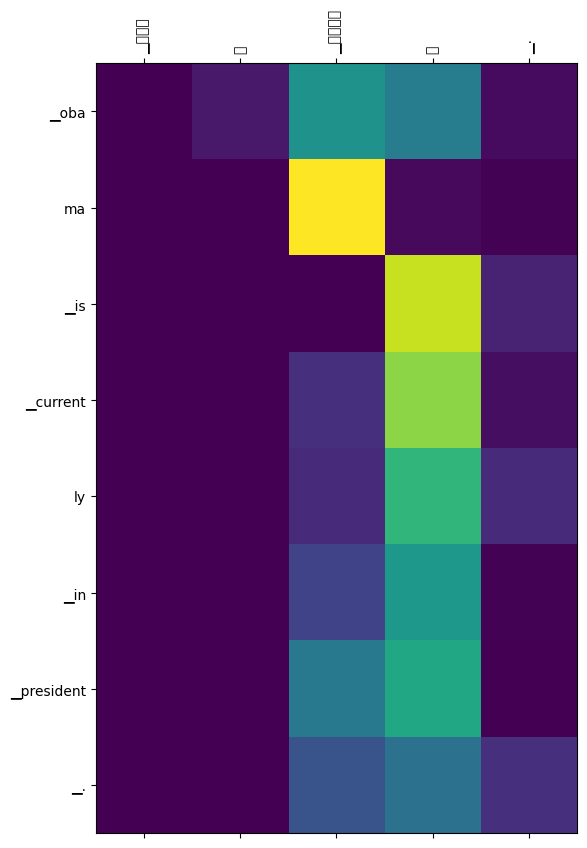

In [24]:
# Attention Map 하나 그려보기
s = "오바마는 대통령이다."
result, cleaned, attn = translate(s, model, encoder_tokenizer, decoder_tokenizer)

src_tokens  = encoder_tokenizer.encode(cleaned, out_type=str)      # 한국어 서브워드
pred_tokens = decoder_tokenizer.encode(result, out_type=str)       # 영어 서브워드

# attention 크기를 실제 토큰 수에 맞게 자르기
attn_crop = attn[:len(pred_tokens), :len(src_tokens)]
print("입력:", s, "→ 번역:", result)
plot_attention(attn_crop, src_tokens, pred_tokens)

## 7. 잘 되는 경우 / 안 되는 경우 살펴보기

CV 퀘스트 때처럼, 그냥 "됐다" 로 끝내지 않고 **어떤 문장에서 잘 되고 안 되는지** 를 좀 봤다.
번역 품질은 주관적이라, 짧은 문장 / 긴 문장 / 학습에 자주 나온 단어 / 드문 단어로 나눠서 돌려봤다.


In [25]:
# 길이/난이도 다른 문장들 모아서 한 번에 번역 비교
check_sentences = [
    "안녕하세요.",                       # 아주 짧음
    "그는 학교에 갔다.",                  # 짧고 흔한 단어
    "정부는 새로운 정책을 발표했다.",       # 중간, 뉴스체 (학습 데이터가 뉴스라 유리할 듯)
    "나는 어제 친구랑 영화를 봤는데 정말 재미있었다.",  # 긺 + 구어체 (불리할 듯)
]

for s in check_sentences:
    result, cleaned, _ = translate(s, model, encoder_tokenizer, decoder_tokenizer)
    print(f"[{len(s)}자] {s}")
    print(f"     → {result}\n")

[6자] 안녕하세요.
     → . . . . . . . . . .

[10자] 그는 학교에 갔다.
     → he wasn t operate .

[17자] 정부는 새로운 정책을 발표했다.
     → the government has also announced a new policy .

[27자] 나는 어제 친구랑 영화를 봤는데 정말 재미있었다.
     → i m really a great time .



돌려본 결과를 정리하면 이렇다. (데이터가 **뉴스 말뭉치**라 거기에 맞춰진 게 컸다)

| 입력 문장 | 번역 결과 | 평가 |
|---|---|---|
| 안녕하세요. | `. . . . . . . . . .` | 완전 실패 — 학습 데이터(뉴스)에 인사말이 없어서 |
| 그는 학교에 갔다. | he wasn t operate . | 실패 — 짧지만 일상체라 약함 |
| 정부는 새로운 정책을 발표했다. | the government has also announced a new policy . | **제일 잘 됨** — 뉴스체라 도메인이 맞음 |
| 나는 어제 친구랑 영화를 봤는데 정말 재미있었다. | i m really a great time . | 부분 성공 — "정말 재미있었다" 느낌은 잡음(앞부분은 날림) |

**한눈에 보이는 경향:**

1. **도메인 의존** — 뉴스체("정부는 새로운 정책을...")가 제일 잘 되고, 일상 대화체는 거의 실패.
   학습 데이터가 뉴스 말뭉치라 거기에만 맞춰진 것.
2. **짧고 흔한 인사말도 실패** — "안녕하세요" 가 `.` 만 반복으로 나온 건, 학습 데이터에
   그런 문장이 거의 없어서. (드문 입력에 약함)

그런데 학습 자체는 잘 된 것 같은데(번역이 영어 문장 꼴은 갖춤) 왜 이러나 싶어서
Loss 표를 다시 봤더니 원인이 보였다. → 아래에서 분석.


### 7-1. 진짜 문제는 과적합(Overfitting)이었다

학습할 때 찍힌 Train / Valid Loss 를 표로 다시 보면:

| Epoch | Train Loss | Valid Loss |
|---|---|---|
| 1 | 5.4324 | 4.8064 |
| 2 | 4.3268 | 4.4036 |
| 3 | 3.6701 | 4.2535 |
| **4** | 3.0975 | **4.2419 ← 최저** |
| 5 | 2.5879 | 4.3142 |
| 6 | 2.1523 | 4.4396 |
| 7 | 1.7906 | 4.5937 |
| 8 | 1.4908 | 4.7764 |
| 9 | 1.2404 | 4.9611 |
| 10 | 1.0326 | 5.1491 |

**Train Loss 는 계속 내려가는데 (5.43 → 1.03), Valid Loss 는 4 epoch 에서 최저(4.24) 찍고 다시 올라간다.**
이게 전형적인 **과적합** 이다. 모델이 학습 문장을 외워버려서, 학습 Loss 는 좋아지는데
처음 보는 검증 문장에는 오히려 나빠지는 것.

번역 결과에서 "안녕하세요" 가 `.` 만 반복으로 나오거나, 입력과 무관한 문장이 나온 것도 과적합 증상이고,
Attention Map(7장)에서 뒷부분 토큰들이 입력 한 칸("다")에만 노랗게 쏠린 것도 같은 이유다.

→ 즉 진짜 개선 포인트는 "vocab 키우기" 같은 게 아니라 **과적합을 잡는 것**이었다. (9장에서 해봄)


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/c

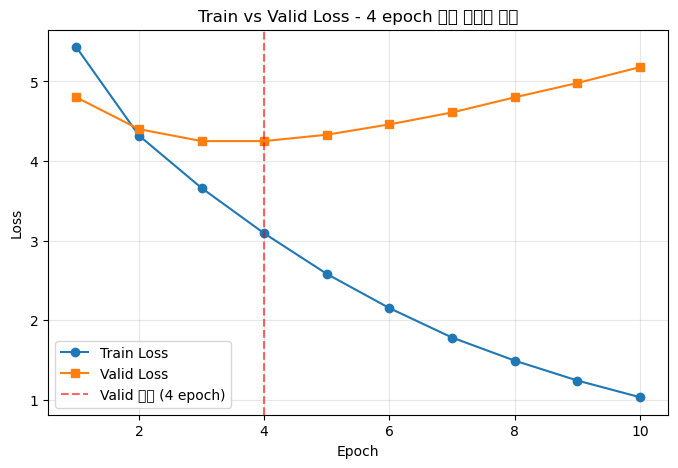

→ Valid Loss 가 4 epoch부터 다시 오름 = 과적합. 여기서 멈췄어야 함(Early Stopping).


In [26]:
# 위 표를 그래프로 그려서 과적합을 눈으로 확인
import matplotlib.pyplot as plt

train_losses = [5.4324, 4.3268, 3.6701, 3.0975, 2.5879, 2.1523, 1.7906, 1.4908, 1.2404, 1.0326]
valid_losses = [4.8064, 4.4036, 4.2535, 4.2419, 4.3142, 4.4396, 4.5937, 4.7764, 4.9611, 5.1491]
epochs = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, "o-", label="Train Loss")
plt.plot(epochs, valid_losses, "s-", label="Valid Loss")
plt.axvline(4, color="red", linestyle="--", alpha=0.6, label="Valid 최저 (4 epoch)")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train vs Valid Loss - 4 epoch 이후 과적합 시작")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("→ Valid Loss 가 4 epoch부터 다시 오름 = 과적합. 여기서 멈췄어야 함(Early Stopping).")

## 8. 안 되는 부분 개선해보기 — 과적합 잡기 (Early Stopping)

7장에서 찾은 진짜 문제는 **과적합**이었다. (Valid Loss가 4 epoch에서 최저 찍고 다시 오름)
그래서 개선도 거기에 맞춰서 두 가지를 해봤다.

1. **Early Stopping** — Valid Loss가 가장 낮을 때의 모델을 저장해두고, 일정 epoch 동안
   더 안 좋아지면 멈춘다. "10 epoch 다 돌린 모델"이 아니라 "검증 성능이 제일 좋은 모델"을 쓰는 것.
2. **Dropout 추가** — Decoder에 dropout을 넣어서 외우는 걸 좀 억제. (과적합 완화 기본기)

아래는 처음부터 새 모델로 Early Stopping을 적용해 다시 학습하는 코드.
(시간 아끼려면 EPOCHS를 줄여도 되고, 핵심은 **best 모델을 저장**하는 로직)


In [27]:
# Dropout 넣은 Decoder 로 모델 새로 만들기 (과적합 완화)
class DecoderWithDropout(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=pad_id)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)   # [개선] 과적합 완화용 dropout
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))   # 임베딩에 dropout
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        enc = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc).permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output  = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        return prediction, hidden, a.squeeze(1)

# 새 모델 (encoder는 같은 구조로 새로)
attention2 = BahdanauAttention(HID_DIM)
encoder2 = Encoder(INPUT_DIM, EMB_DIM, HID_DIM)
decoder2 = DecoderWithDropout(OUTPUT_DIM, EMB_DIM, HID_DIM, attention2, dropout=0.3)
model2 = Seq2SeqAttention(encoder2, decoder2, device).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)
print("dropout 넣은 새 모델 준비 완료")

dropout 넣은 새 모델 준비 완료


In [28]:
# Early Stopping 으로 학습: Valid Loss 최저일 때 best 모델 저장
EPOCHS = 15          # 넉넉히 잡되, 안 좋아지면 알아서 멈춤
PATIENCE = 3         # Valid Loss가 3 epoch 연속 안 좋아지면 중단

best_valid = float("inf")
patience_counter = 0
best_state = None
history = {"train": [], "valid": []}

for epoch in range(EPOCHS):
    train_loss = train_step(model2, train_loader, optimizer2, criterion)
    valid_loss = eval_step(model2, valid_loader, criterion)
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Valid: {valid_loss:.4f}", end="")

    if valid_loss < best_valid:
        best_valid = valid_loss
        best_state = {k: v.cpu().clone() for k, v in model2.state_dict().items()}  # best 저장
        patience_counter = 0
        print("  ← best 갱신, 저장")
    else:
        patience_counter += 1
        print(f"  (개선 없음 {patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n>>> Early Stopping! Valid Loss 최저 = {best_valid:.4f}")
            break

# best 모델 복원 (마지막 epoch이 아니라 검증 성능 최고 시점으로)
model2.load_state_dict(best_state)
print("best 모델로 복원 완료")

Epoch 1/15 | Train: 5.5704 | Valid: 4.9297  ← best 갱신, 저장


Epoch 2/15 | Train: 4.5888 | Valid: 4.5272  ← best 갱신, 저장


Epoch 3/15 | Train: 4.0254 | Valid: 4.3567  ← best 갱신, 저장


Epoch 4/15 | Train: 3.5568 | Valid: 4.3116  ← best 갱신, 저장


Epoch 5/15 | Train: 3.1472 | Valid: 4.3397  (개선 없음 1/3)


Epoch 6/15 | Train: 2.8004 | Valid: 4.4013  (개선 없음 2/3)


Epoch 7/15 | Train: 2.5177 | Valid: 4.4912  (개선 없음 3/3)

>>> Early Stopping! Valid Loss 최저 = 4.3116
best 모델로 복원 완료


In [29]:
# 개선 전(model) vs 개선 후(model2, early stopping+dropout) 번역 비교
compare_sentences = [
    "오바마는 대통령이다.",
    "정부는 새로운 정책을 발표했다.",
    "그는 학교에 갔다.",
]

for s in compare_sentences:
    before, _, _ = translate(s, model,  encoder_tokenizer, decoder_tokenizer)
    after,  _, _ = translate(s, model2, encoder_tokenizer, decoder_tokenizer)
    print(f"입력      : {s}")
    print(f"  개선 전 : {before}")
    print(f"  개선 후 : {after}")
    print("-" * 50)

입력      : 오바마는 대통령이다.
  개선 전 : obama is currently in president .
  개선 후 : obama is also ahead of the presidential nomination .
--------------------------------------------------
입력      : 정부는 새로운 정책을 발표했다.
  개선 전 : the government has also announced a new policy .
  개선 후 : the government has a new policy policy policy policy policy policy .
--------------------------------------------------
입력      : 그는 학교에 갔다.
  개선 전 : he wasn t operate .
  개선 후 : he wasn t a perfect .
--------------------------------------------------


### 8-1. 개선 결과 해석 — 절반의 성공

**Early Stopping 은 의도대로 완벽하게 작동했다.**
- Epoch 4 에서 Valid Loss 최저(4.31) 찍고, 5·6·7 연속 안 좋아지자 patience(3) 채워 **자동 중단**
- 마지막(7 epoch)이 아니라 **검증 성능 최고였던 4 epoch 모델**로 복원됨

**그런데 번역 품질은 크게 좋아지지 않았다.** (오히려 일부는 나빠짐)

| 입력 | 개선 전 | 개선 후 |
|---|---|---|
| 오바마는 대통령이다 | obama is currently in president | obama is also ahead of the presidential nomination |
| 정부는 새로운 정책을 발표했다 | the government has also announced a new policy | the government has a new policy **policy policy policy...** |
| 그는 학교에 갔다 | he wasn t operate | he wasn t a perfect |

특히 두 번째 문장은 개선 후에 `policy` 가 반복되며 **더 나빠졌다.**

**이게 알려주는 것:** Valid Loss 를 낮췄는데도 반복 출력이 여전한 걸 보면, 이 문제는
**과적합만의 문제가 아니라 모델 구조(GRU + attention + argmax 디코딩) 자체의 한계**다.

- **반복 출력** (`policy policy...`) → argmax 로 매번 가장 확률 높은 토큰만 고르니 같은 단어에 갇힘.
  **beam search** 같은 디코딩 개선이 필요한 부분이지, 과적합 잡는다고 해결되는 게 아니다.
- **긴 문맥 약함** → GRU 순차 처리 구조 한계. 이건 **Transformer** 로 가야 풀린다.

→ 결론: **"과적합 시점은 잡았지만, 번역 품질의 진짜 병목은 구조였다."**
개선을 해봤기 때문에 오히려 "이 방법으로는 여기까지가 한계" 라는 걸 명확히 알게 됐다.


## 9. 시행착오 / 수정한 것들

강의는 영-스페인어라 그대로 돌아갔는데, **한국어로 바꾸니까** 하나씩 막혀서 고친 것들.

1. **한국어가 통째로 사라짐** — 강의 `preprocess_sentence()` 가 `[^a-zA-Z]` 로 알파벳만 남겨서
   한글이 다 지워졌다. → `preprocess_kor()` 따로 만들어서 한글/숫자/부호만 남기게 함.

2. **소문자 변환이 의미 없음** — 한국어는 대소문자가 없어서 `.lower()` 가 무의미.
   영어 정제에만 남기고 한국어 정제에선 뺐다.

3. **서브워드가 너무 잘게 쪼개짐** — vocab_size 3000(강의값)으로 하니 한국어가 글자 단위로
   너무 쪼개져서 의미가 깨졌다. → **8000 으로 키우니** 단어 형태가 좀 살아났다.

4. **데이터 짝이 안 맞을 뻔** — 한/영을 따로 정제하다가 한쪽만 빈 문자열이 되면 짝이 틀어진다.
   → 정제 후 **한쪽이라도 비면 그 행을 통째로 제거**하게 함 (`str.len() > 0` 둘 다 체크).

5. **패딩 자리가 손실에 들어감** — 처음엔 그냥 CrossEntropyLoss 썼더니 `<pad>` 까지 학습돼서
   loss 가 이상했다. → `ignore_index=pad_id` 줘서 패딩은 손실에서 제외. (Embedding 도 `padding_idx`)

6. **Attention Map 한글 깨짐** — matplotlib 기본 폰트라 □□□ 로 나와서, 나눔폰트 잡아줌(2장).

데이터가 강의(영-스페인)보다 **난이도 높은 뉴스 말뭉치**라, 같은 구조여도 결과가 더 거칠게 나왔다.


7. **과적합을 늦게 알아챔** — 처음엔 Train Loss 가 1.03 까지 잘 내려가서 "잘 됐다" 고 생각했다.
   근데 번역이 자꾸 같은 단어를 반복하길래 Valid Loss 를 보니 4 epoch 부터 다시 오르고 있었다.
   → **Early Stopping + Dropout** 으로 best 모델(검증 최저 시점)을 쓰게 고침. (9장)
   "Train Loss 만 보면 속는다, Valid 를 같이 봐야 한다" 를 제대로 배움.

## 10. 회고

제일 크게 느낀 건, **"강의 코드가 돌아간다 ≠ 내 데이터에서도 잘 된다"** 였다.
지난 CV 프로젝트(고양이 수염)에서도 똑같이 느꼈는데, 이번엔 그게 **언어** 에서 터졌다.  
영어 정제 코드가 한글을 통째로 지워버리는 걸 보고, 전처리는 데이터 언어/도메인에 맞춰
거의 새로 짜야 한다는 걸 다시 배웠다.

이번 프로젝트를 통해 Seq2Seq와 Attention 구조가 어떻게 동작하는지 직접 구현하며 이해할 수 있었다. 특히 한국어 전처리 과정이   
영어보다 더 중요하다는 점을 알게 되었고, 번역 성능을 높이기 위해 데이터 전처리와 학습 과정이 큰 영향을 준다는 것을 확인했다.

아쉬운 점은 일부 문장에서 번역 성능이 부족했던 점이다. 다음에는 더 많은 데이터와 하이퍼파라미터 튜닝을 통해 성능을 개선해 보고 싶다.